In [1]:
# Libraries

import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm


sys.path.append('../')
from simulation.config import *

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
from models.model_architectures import ParticleNet, ParticleNetSCFC

In [3]:
model_1 = ParticleNet().to(device)
model_1.load_state_dict(torch.load(f'../models/particle_net.pth', map_location=device))
model_1.eval()
print(f'Loaded particle_net.pth for inference')

model_2 = ParticleNetSCFC().to(device)
model_2.load_state_dict(torch.load(f'../models/particle_net_scfc.pth', map_location=device))
model_2.eval()
print(f'Loaded particle_net_scfc.pth for inference')

Loaded particle_net.pth for inference
Loaded particle_net_scfc.pth for inference


In [4]:
dataset = np.load('../particle_dataset.npy')  # Shape: (100, 303, 100, 11)
print(f'Loaded dataset with shape: {dataset.shape}')

Loaded dataset with shape: (100, 304, 100, 10)


In [5]:
# Dataset preprocessing
num_trials, max_timesteps, num_particles, num_features = dataset.shape
assert num_features == 11, f"Expected 11 features, got {num_features}. Adjust preprocessing if dataset has fewer features."

AssertionError: Expected 11 features, got 10. Adjust preprocessing if dataset has fewer features.

In [7]:
# Select a single particle for comparison
particle_idx = 0
single_particle_data = dataset[:, :, particle_idx, :]  # Shape: (num_trials, max_timesteps, 11)

# Create input-output pairs
inputs, targets = [], []
for trial_idx in range(num_trials):
    for t in range(max_timesteps - 1):  # Predict next state
        inputs.append(single_particle_data[trial_idx, t, :])  # [x, y, e, vx0, vy0, g, Δt, x_min, x_max, n*]
        targets.append(single_particle_data[trial_idx, t + 1, :2])  # [x, y]
inputs = np.array(inputs, dtype=np.float32)  # Shape: (num_trials*(max_timesteps-1), 11)
targets = np.array(targets, dtype=np.float32)  # Shape: (num_trials*(max_timesteps-1), 2)
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

Inputs shape: (30300, 10), Targets shape: (30300, 2)


In [8]:
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=test_size, random_state=42)
print(f'Test set: {X_test.shape}, {y_test.shape}')

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

Test set: (3030, 10), (3030, 2)


In [9]:
# Inference
def run_inference(model, inputs):
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in tqdm(range(0, inputs.size(0), 64), desc="Inference"):
            batch = inputs[i:i+64]
            output = model(batch)
            predictions.append(output.cpu().numpy())
    return np.concatenate(predictions, axis=0)

In [10]:
# Run inference for both models
predictions_1 = run_inference(model_1, X_test_tensor)  # ParticleNet
predictions_2 = run_inference(model_2, X_test_tensor)  # ParticleNetSCFC

print(f'Predictions shape for ParticleNet: {predictions_1.shape}')
print(f'Predictions shape for ParticleNetSCFC: {predictions_2.shape}')

Inference: 100%|██████████| 48/48 [00:00<00:00, 984.21it/s]

Predictions shape for ParticleNet: (3030, 2)
Predictions shape for ParticleNetSCFC: (3030, 2)


In [11]:
# Compute MSE for each model
criterion = nn.MSELoss(reduction='mean')
mse_1 = criterion(torch.tensor(predictions_1), y_test_tensor.cpu()).item()
mse_2 = criterion(torch.tensor(predictions_2), y_test_tensor.cpu()).item()
print(f'ParticleNet MSE: {mse_1:.6f}')
print(f'ParticleNetSCFC MSE: {mse_2:.6f}')

ParticleNet MSE: 515.123474
ParticleNetSCFC MSE: 511.100952


In [12]:
# Component-wise MSE
def component_mse(predictions, targets):
    mse_components = np.mean((predictions - targets) ** 2, axis=0)
    return mse_components

In [13]:
mse_components_1 = component_mse(predictions_1, y_test)
mse_components_2 = component_mse(predictions_2, y_test)
components = ['x', 'y']
print("\nComponent-wise MSE:")
print(f"{'Component':<10} {'ParticleNet':<15} {'ParticleNetSCFC':<15}")
for i, comp in enumerate(components):
    print(f"{comp:<10} {mse_components_1[i]:<15.6f} {mse_components_2[i]:<15.6f}")


Component-wise MSE:
Component  ParticleNet     ParticleNetSCFC
x          980.873352      966.652222     
y          49.374191       55.548695      


In [16]:
# Visualize trajectories for one trial
# Select a trial from the test set
trial_length = max_timesteps - 1
# Find a trial in the test set
test_indices = np.random.choice(np.arange(inputs.shape[0]), size=X_test.shape[0], replace=False)
trial_idx = test_indices[0] // trial_length  # Approximate trial index
trial_start_idx = trial_idx * trial_length
trial_inputs = inputs[trial_start_idx:trial_start_idx + trial_length, :]
trial_targets = targets[trial_start_idx:trial_start_idx + trial_length, :]

# Run inference for the trial
trial_inputs_tensor = torch.tensor(trial_inputs, dtype=torch.float32).to(device)
with torch.no_grad():
    trial_pred_1 = model_1(trial_inputs_tensor).cpu().numpy()
    trial_pred_2 = model_2(trial_inputs_tensor).cpu().numpy()

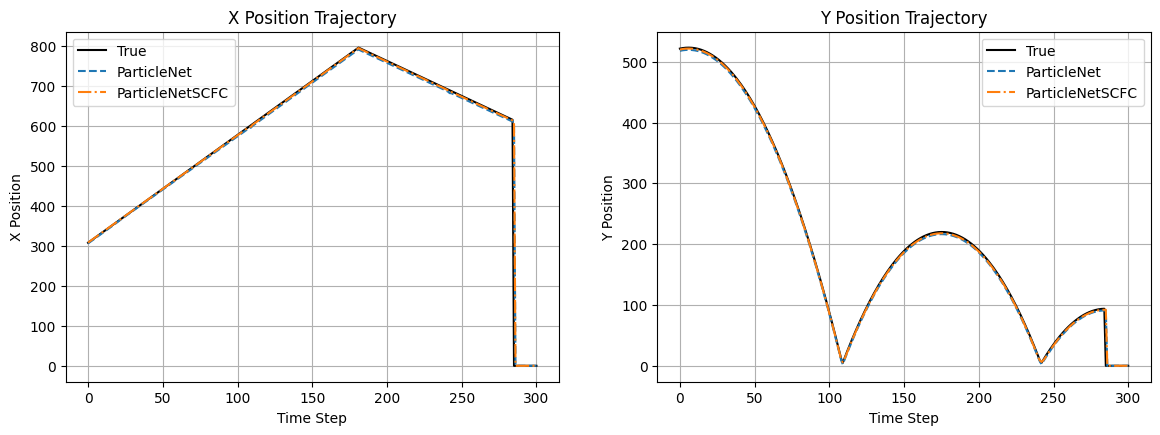

In [18]:
# Plot trajectories
plt.figure(figsize=(14, 10))

# X-position
plt.subplot(2, 2, 1)
plt.plot(trial_targets[:, 0], label='True', color='black')
plt.plot(trial_pred_1[:, 0], label='ParticleNet', linestyle='--')
plt.plot(trial_pred_2[:, 0], label='ParticleNetSCFC', linestyle='-.')
plt.xlabel('Time Step')
plt.ylabel('X Position')
plt.title('X Position Trajectory')
plt.legend()
plt.grid(True)

# Y-position
plt.subplot(2, 2, 2)
plt.plot(trial_targets[:, 1], label='True', color='black')
plt.plot(trial_pred_1[:, 1], label='ParticleNet', linestyle='--')
plt.plot(trial_pred_2[:, 1], label='ParticleNetSCFC', linestyle='-.')
plt.xlabel('Time Step')
plt.ylabel('Y Position')
plt.title('Y Position Trajectory')
plt.legend()
plt.grid(True)